# Figure 4 Jupyter Notebook

## Imports and Common Functions

In [1]:
import glob
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def sort_func(filename):
    file_parts = filename.split('_')
    try:
        return int(file_parts[-1].split('.')[0])
    except ValueError:
        return 0


def shrink_array(arr, factor):
    """Re-bin an array by an integer factor.
    In the new array, each bin is the sum of the original bins.
    """
    old_shape = arr.shape
    new_shape = (old_shape[0] // factor, old_shape[1] // factor)
    new_arr = np.zeros(new_shape)
    for i in range(new_shape[0]):
        for j in range(new_shape[1]):
            new_arr[i, j] = np.sum(arr[i*factor:(i+1)*factor, j*factor:(j+1)*factor])
    return new_arr


def shrink_array_roll(arr, factor: int, offset_0: int = 0, offset_1: int = 0):
    """Offset the array by a given amount and then re-bin it with integer factor.
    """
    offset_0 = offset_0 % factor
    offset_1 = offset_1 % factor
    rolled_array = np.roll(arr, (offset_0, offset_1), axis=(0, 1))
    return shrink_array(rolled_array, factor)


def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [3]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_04_07/afc_longterm/2D')
files_to_include = 16

# plotting params
cmap_name = 'magma'
cmap = plt.get_cmap(cmap_name)
new_cmap = truncate_colormap(cmap, minval=0.1, maxval=1.0)

In [4]:
# data processing params
signal_idler_offset_guess = 453  # verified based on bidirectional histogram maximum
echo_center = 2456  # guessing this value based on the echo histogram, verified based on minimum error
idler_lim_input = (300, 1300)
rebin_factor = 12

In [5]:
bin_size = 0.5  # unit: ns
storage_time = 1000  # unit: ns
repetition_time = 2000 # unit: ns

integration_time = files_to_include * 3600  # unit: s
num_pulses = integration_time * 500e3  # 500 kHz rep rate

idler_waveguide_efficiency = 0.049
signal_waveguide_efficiency = 0.07
signal_feedthrough_efficiency = 0.85
snspd_52_efficiency = 0.4532 * 0.7274   # includes filter loss and detector inefficiency
snspd_48_efficiency = 0.4790 * 0.9260

In [6]:
all_files = glob.glob(os.path.join(DATA_DIR, '*.npz'))
all_files.sort(key=sort_func)

# load data
all_counts = []
all_bins = []
all_freqs = []
file_numbers = []
for file in all_files:
    try:
        file_number = int(file.split('/')[-1].split('.')[0].split('_')[-1])
    except ValueError:
        file_number = 0
    file_numbers.append(file_number)

    data = np.load(file)
    counts = data['counts']
    bins = data['bins']
    freqs_start = data['freq_start']
    freqs_end = data['freq_end']
    all_counts.append(counts)
    all_bins.append(bins)
    all_freqs.append((freqs_start, freqs_end))

all_hist = np.sum(all_counts[:files_to_include], axis=0)

## Subfigure (a): Coincidence 2D Histogram

In [7]:
offset_0 = -echo_center
rebinned_array = shrink_array_roll(all_hist, factor=rebin_factor, offset_0=offset_0)

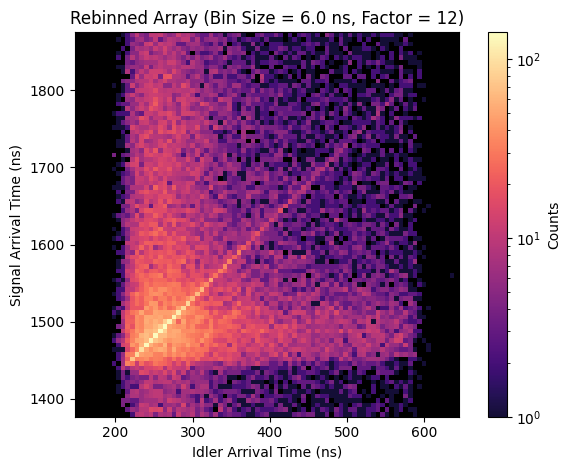

In [8]:
# plot summed histogram (zoom on echo)
signal_start = (idler_lim_input[0] + signal_idler_offset_guess + 2000) // rebin_factor + 1
signal_end = (idler_lim_input[1] + signal_idler_offset_guess + 2000) // rebin_factor + 1
idler_start = idler_lim_input[0] // rebin_factor
idler_end = idler_lim_input[1] // rebin_factor
echo_zoom = rebinned_array[signal_start:signal_end, idler_start:idler_end]

signal_time_bins = np.arange(signal_start, signal_end) * rebin_factor * bin_size
idler_time_bins = np.arange(idler_start, idler_end) * rebin_factor * bin_size
X, Y = np.meshgrid(idler_time_bins, signal_time_bins)

# plot log scale
plt.pcolormesh(X, Y, echo_zoom, cmap=new_cmap,
               norm=colors.LogNorm(vmin=1, vmax=echo_zoom.max()))
plt.gca().set_facecolor('black')
plt.gca().set_aspect('equal')
plt.xlabel('Idler Arrival Time (ns)')
plt.ylabel('Signal Arrival Time (ns)')
plt.colorbar(label='Counts')
plt.title(f'Rebinned Array (Bin Size = {rebin_factor * bin_size} ns, Factor = {rebin_factor})')
plt.tight_layout()

## Subfigure (b): Diagonal Coincidence Bins

In [9]:
time_bin_diagonal = np.diagonal(echo_zoom)
bin_numbers = np.arange(len(time_bin_diagonal))

In [10]:
# define starting and ending bins
start_bin = 13
frame_size = 12

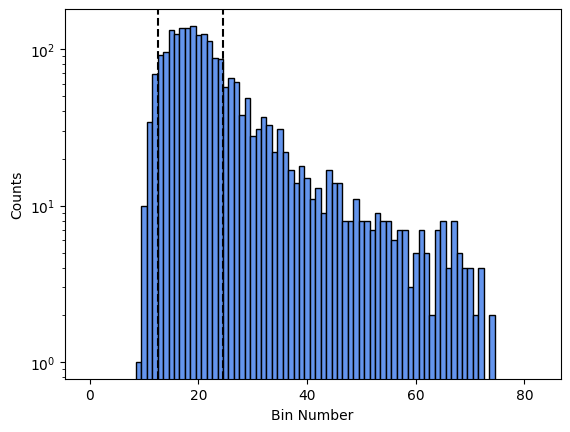

In [11]:
plt.bar(bin_numbers, time_bin_diagonal, width=1, color='cornflowerblue', edgecolor='k')
plt.axvline(x=start_bin-0.5, color='k', linestyle='--')
plt.axvline(x=start_bin+frame_size-0.5, color='k', linestyle='--')
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.yscale('log')

## Subfigure (c): Performance Characterization

In [12]:
# frame_sizes = np.arange(10, 70, 1, dtype=int)
frame_sizes = np.arange(2, 65, 1, dtype=int)
min_start_idx = 0
max_max_start_idx = len(time_bin_diagonal) - min(frame_sizes)
entropies = np.empty((len(frame_sizes), max_max_start_idx + 1))
entropies[:] = np.nan
total_ebits = np.empty((len(frame_sizes), max_max_start_idx + 1))
total_ebits[:] = np.nan
rate_ebits = np.empty((len(frame_sizes), max_max_start_idx + 1))
rate_ebits[:] = np.nan

for i, bin_num in enumerate(frame_sizes):
    max_start_idx = len(time_bin_diagonal) - bin_num
    pulse_time = bin_num * bin_size * rebin_factor  # unit: ns
    pulse_duty_cycle = pulse_time / repetition_time

    for j, start_idx in enumerate(range(min_start_idx, max_start_idx)):
        end_idx = start_idx + bin_num
        time_bins_to_analyze = time_bin_diagonal[start_idx:end_idx]
        counts_tot = np.sum(time_bins_to_analyze)
        amplitudes = time_bins_to_analyze / counts_tot
        entropy = 0
        for amplitude in amplitudes:
            if amplitude > 0:
                entropy -= amplitude * np.log2(amplitude)

        entropies[i, j] = entropy
        total_counts_entropy = counts_tot * entropy
        total_ebits[i, j] = total_counts_entropy

        ebit_rate = total_counts_entropy / (integration_time * pulse_duty_cycle)
        rate_ebits[i, j] = ebit_rate

all_efficiencies = idler_waveguide_efficiency * signal_waveguide_efficiency * signal_feedthrough_efficiency * snspd_52_efficiency * snspd_48_efficiency
rate_ebits_no_loss = rate_ebits / all_efficiencies

/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_12446/3951529695.py:21: RuntimeWarning: invalid value encountered in divide
  amplitudes = time_bins_to_analyze / counts_tot


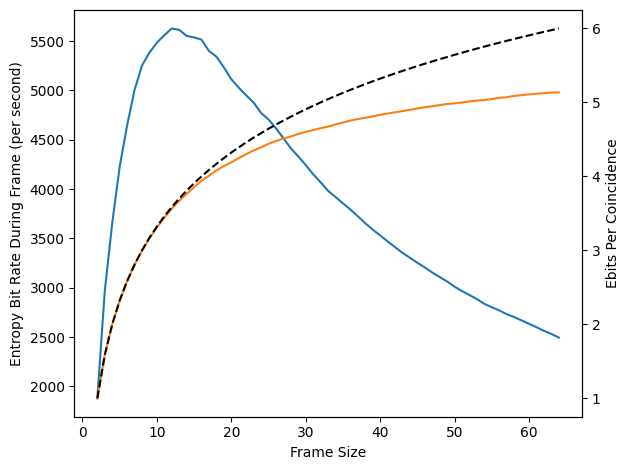

In [13]:
max_rates = np.nanmax(rate_ebits_no_loss, axis=1)
max_rates_idx = np.nanargmax(rate_ebits_no_loss, axis=1)
ebits_per_coincidence = np.array([entropies[i, j] for i, j in enumerate(max_rates_idx)])

fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(frame_sizes, max_rates)
ax.set_xlabel('Frame Size')
ax.set_ylabel('Entropy Bit Rate During Frame (per second)')

ax2.plot(frame_sizes, ebits_per_coincidence, color='tab:orange')
ax2.plot(frame_sizes, np.log2(frame_sizes), '--k')
ax2.set_ylabel('Ebits Per Coincidence')

fig.tight_layout()

In [14]:
max_rate_idx = np.argmax(max_rates)

# Main Plot Code

First, define plotting parameters

In [15]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figwidth_mm = 90
figsize = (figwidth_mm/25.4, 5)  # inches
dpi = 300
include_subplot_titles = False

# colors
color_primary = '#7570b3'
color_gray = 'darkgray'
color_secondary = '#d95f02'

# figure layout
vertical_padding = 0.05
horizontal_padding = 0.05

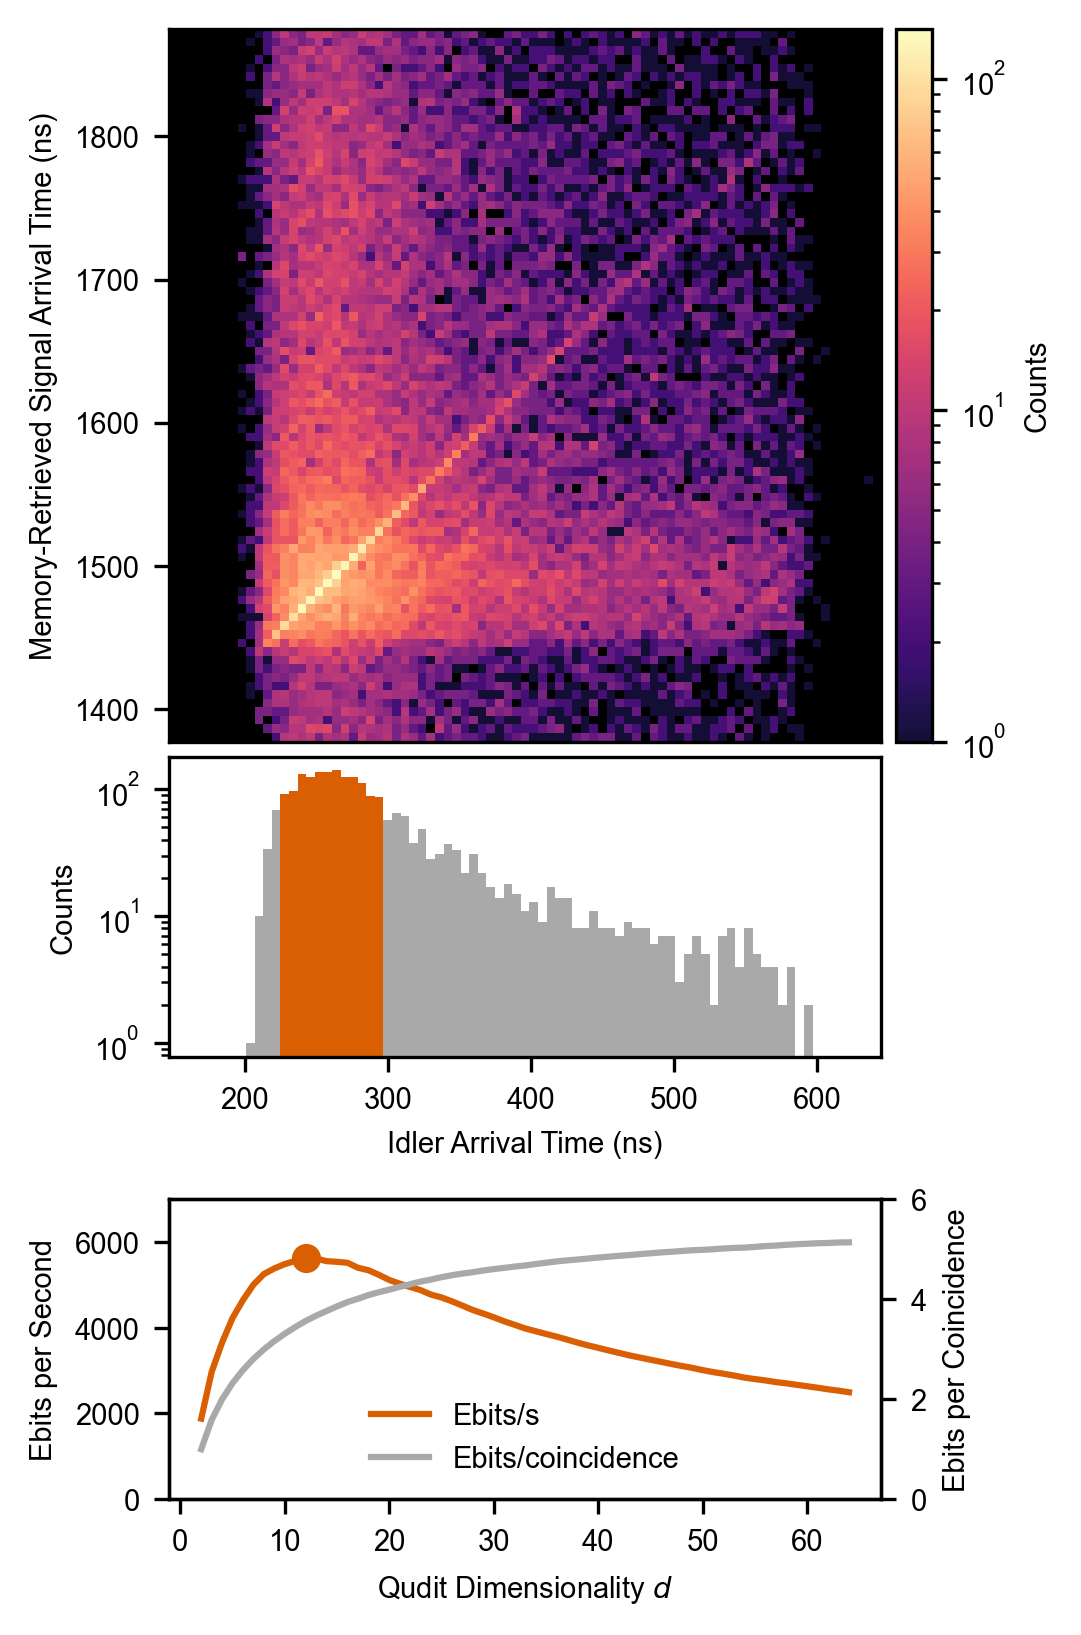

In [21]:
fig = plt.figure(layout='constrained', figsize=figsize, dpi=dpi)
fig.get_layout_engine().set(w_pad=horizontal_padding, h_pad=vertical_padding)
subfigs = fig.subfigures()
ax_top = subfigs.subplots()

divider = make_axes_locatable(ax_top)
ax_mid = divider.append_axes('bottom', 1, pad=0.05, sharex=ax_top)
ax_bot = divider.append_axes('bottom', 1)
ax_bot_right = ax_bot.twinx()
cax = divider.append_axes('right', size='5%', pad=0.05)

plot = ax_top.pcolormesh(X, Y, echo_zoom, cmap=new_cmap,
                         norm=colors.LogNorm(vmin=1, vmax=echo_zoom.max()))
ax_top.set_facecolor('black')
ax_top.axes.set_aspect('equal')
ax_top.set_ylabel('Memory-Retrieved Signal Arrival Time (ns)')
ax_top.xaxis.set_visible(False)

subfigs.colorbar(plot, cax=cax, label='Counts', ax=ax_top)

idler_time_bins_frame = idler_time_bins[start_bin:start_bin+frame_size]
counts_frame = time_bin_diagonal[start_bin:start_bin+frame_size]
ax_mid.bar(idler_time_bins, time_bin_diagonal,
           width=rebin_factor*bin_size, color=color_gray)
ax_mid.bar(idler_time_bins_frame, counts_frame,
           width=rebin_factor*bin_size, color=color_secondary)
ax_mid.set_yscale('log')
ax_mid.set_xlabel('Idler Arrival Time (ns)')
ax_mid.set_ylabel('Counts')

lns_rate = ax_bot.plot(frame_sizes, max_rates, color=color_secondary,
                       label='Ebits/s')
lns_coinc = ax_bot_right.plot(frame_sizes, ebits_per_coincidence, color=color_gray,
                              label='Ebits/coincidence')
# add highlight of max rate
ax_bot.plot(frame_sizes[max_rate_idx], max_rates[max_rate_idx], 'o', color=color_secondary)
ax_bot.set_ylim(0, 7000)
ax_bot_right.set_ylim(0, 6)
ax_bot.set_xlabel(r'Qudit Dimensionality $d$')
ax_bot.set_ylabel('Ebits per Second')
ax_bot_right.set_ylabel('Ebits per Coincidence')
lns = lns_rate + lns_coinc
labs = [l.get_label() for l in lns]
ax_bot.legend(lns, labs, frameon=False, loc='lower center')

In [22]:
fig.savefig('fig4_rate.pdf', bbox_inches='tight')